## Pre-training Compass from Scracth

Pretraining is a critical component of the COMPASS framework, providing biologically meaningful representations of gene expression profiles before fine-tuning on specific clinical tasks. In this workflow, we demonstrate how COMPASS can be pretrained on **TCGA transcriptomic data**, using bulk RNA-seq TPM matrices as input. The model employs a **contrastive learning strategy**, where positive and negative pairs are constructed across patients to capture robust and generalizable gene–concept relationships.

COMPASS is designed as a **concept-bottleneck model**: instead of learning from tens of thousands of individual genes, the encoder learns to embed transcriptomic features into **132 intermediate gene sets**, which are then projected into **44 high-level TIME concepts**. This hierarchical design ensures both dimensionality reduction and interpretability, grounding the learned representations in known biological processes.

During pretraining, several configurations were chosen based on empirical results and prior studies:

* **Batch size:** We recommend using the largest possible batch size (e.g., 2048 or 4096 on high-memory GPUs), as contrastive learning benefits from more negative samples per update. In practice, GPU memory often limits batch size when training with ~1,000–15,000 input genes, so values of 128–512 are typically used.
* **Learning rate:** A default learning rate of **1e-4 to 5e-5** balances stable optimization and generalization.
* **Epochs and patience:** Training for 30~200 epochs with an early-stopping patience of 50 epochs prevents overfitting while ensuring sufficient convergence.
* **Input features:** Pretraining can be done with either the **full gene space (e.g., 15,672 genes)** or a **restricted set of concept-related genes (e.g., 1,065 genes)**. Restricting to concept genes improves efficiency while maintaining competitive performance, making it a practical alternative when computational resources are limited.

The pretrained COMPASS model thus serves as a **feature extractor**, generating stable and interpretable concept-level embeddings. These embeddings can then be fine-tuned on downstream tasks such as **response prediction, survival modeling, or biomarker discovery**, allowing COMPASS to integrate large-scale transcriptomic data with clinical applications.


In [1]:
from compass import PreTrainer, FineTuner, loadcompass
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Load the example dataset for pretraining
# We provide sample datasets contain gene expression data for training and testing
# Ensure the data is preprocessed appropriately before use
tcga_train_sample = pd.read_csv('https://www.immuno-compass.com/download/other/tcga_example_train.tsv', sep='\t', index_col=0)
tcga_test_sample = pd.read_csv('https://www.immuno-compass.com/download/other/tcga_example_test.tsv', sep='\t', index_col=0)

Epoch: 1/200 - Train Loss: 0.9182 - Test Loss: 0.9010
Epoch: 2/200 - Train Loss: 0.9064 - Test Loss: 0.9033
Epoch: 3/200 - Train Loss: 0.8853 - Test Loss: 0.8917
Epoch: 4/200 - Train Loss: 0.8942 - Test Loss: 0.8561
Epoch: 5/200 - Train Loss: 0.8835 - Test Loss: 0.8803
Epoch: 6/200 - Train Loss: 0.8874 - Test Loss: 0.8764
Epoch: 7/200 - Train Loss: 0.8752 - Test Loss: 0.8525
Epoch: 8/200 - Train Loss: 0.8699 - Test Loss: 0.8485
Epoch: 9/200 - Train Loss: 0.8678 - Test Loss: 0.8610
Epoch: 10/200 - Train Loss: 0.8648 - Test Loss: 0.8544
Epoch: 11/200 - Train Loss: 0.8526 - Test Loss: 0.8257
Epoch: 12/200 - Train Loss: 0.8633 - Test Loss: 0.8236
Epoch: 13/200 - Train Loss: 0.8651 - Test Loss: 0.8461
Epoch: 14/200 - Train Loss: 0.8422 - Test Loss: 0.8399
Epoch: 15/200 - Train Loss: 0.8484 - Test Loss: 0.8281
Epoch: 16/200 - Train Loss: 0.8559 - Test Loss: 0.8032
Epoch: 17/200 - Train Loss: 0.8390 - Test Loss: 0.8211
Epoch: 18/200 - Train Loss: 0.8170 - Test Loss: 0.8313
Epoch: 19/200 - Tra

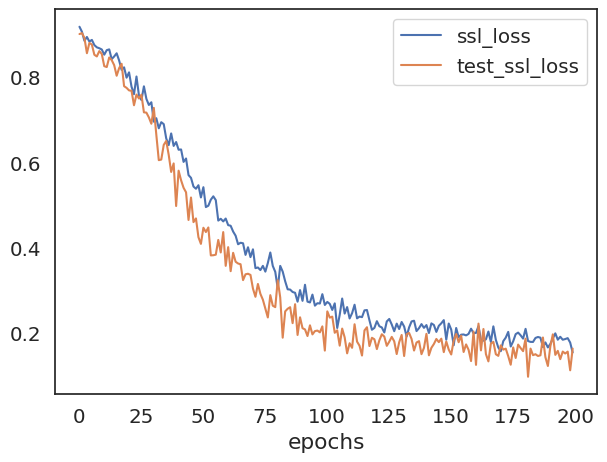

In [4]:
# Define pretraining hyperparameters
pt_args = {'lr': 5e-5, 'batch_size': 128, 'epochs': 200, 'seed':42, 'patience':50}
pretrainer = PreTrainer(**pt_args)

# Train the model using the provided training and test datasets
# - dfcx_train: Training dataset
# - dfcx_test: Validation dataset to monitor performance
pretrainer.train(dfcx_train=tcga_train_sample,
                 dfcx_test=tcga_test_sample)

# Save the trained pretrainer model for future use
pretrainer.save('./results/pretrainer.pt')